In [1]:
import numpy as np
import matplotlib.pyplot as plt
import utils.tx_rx_system as tx_rx_system

## MODULACIÓ OOK AMB SENYAL SIMULADA

### 1. Codificació del senyal

Per tal de realitzar la codificació del senyal, se segueixen els passos següents:

- **Generació del senyal**:  
  Es genera el senyal base utilitzant el mètode de codificació del mòdul `tx_rx_system`. En aquest mètode, s’especifica el tipus de codificació (OOK o Manchester), el missatge que es vol transmetre i el nombre de repeticions.  
  Aquesta funció codifica el missatge afegint:
  - una **start sequence**, equivalent a `10101010` (OOK) o `1001100110011001` (Manchester),
  - un **preamble** de 8 bits que indica la longitud del missatge,
  - i finalment el missatge convertit a format binari.

- **Conversió del senyal**:  
  Finalment, s’executa l’script `csv2arb.py` per preparar el fitxer i convertir-lo a format `.arb` de 4096 punts, de manera que pugui ser carregat al generador de funcions.

Senyal guardat a fitxers/senyal.csv
Executing: python3 utils/csv2arb.py fitxers/senyal.csv
Conversion complete. ARB file saved as 'fitxers/senyal.arb'.


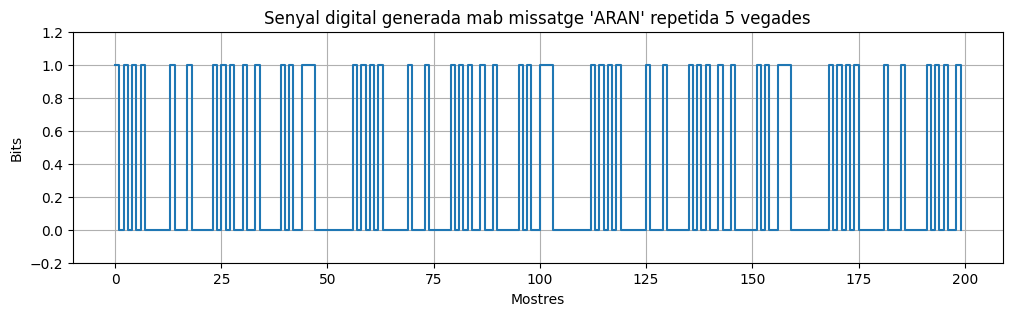

In [2]:
tx_rx_system.codificar(mode="OOK", message="ARAN", num_repeats=5)
signal = np.loadtxt("fitxers/senyal.csv", delimiter=',')[:200]

plt.figure(figsize=(12,3))
plt.step(range(len(signal)), signal, where='post')
plt.ylim(-0.2, 1.2)
plt.xlabel("Mostres")
plt.ylabel("Bits")
plt.title("Senyal digital generada mab missatge 'ARAN' repetida 5 vegades")
plt.grid()
plt.show()

### 2. Descodificació del senyal

Un cop el senyal ha estat enviat al LED driver i capturat pel receptor mitjançant l’oscil·loscopi, es procedeix a la seva descodificació.

En primer lloc, cal netejar el fitxer `.csv` obtingut. Per fer-ho, s’utilitza la funció `convertir_senyal_osciloscopi`, amb l’objectiu d’obtenir únicament un vector amb els valors mostrejats del senyal.

Posteriorment, es calcula el *sample rate* per determinar quantes mostres corresponen a cada bit. Per fer aquest càlcul, es considera que:

- L’oscil·loscopi mostreja a 2.5 kSa/s, de manera que el temps per mostra és:
  `time_per_sample = 1 / sampling_rate`
- El senyal transmès conté 4096 punts i es transmet durant 10 segons, per tant el temps per bit és:
  `time_bit = time_recording / total_bits_recording`

Finalment, es calcula la relació entre ambdós valors per obtenir:
`bits_per_sample = time_bit / time_per_sample`

Un cop conegut aquest valor, s’utilitza la funció `decodificar`, que:
- realitza la correlació del senyal amb la *starting sequence*,
- identifica l’inici dels frames,
- i mostreja al centre de cada bit (50/2).

D’aquesta manera, s’obtenen els diferents frames detectats i es recupera el missatge original.

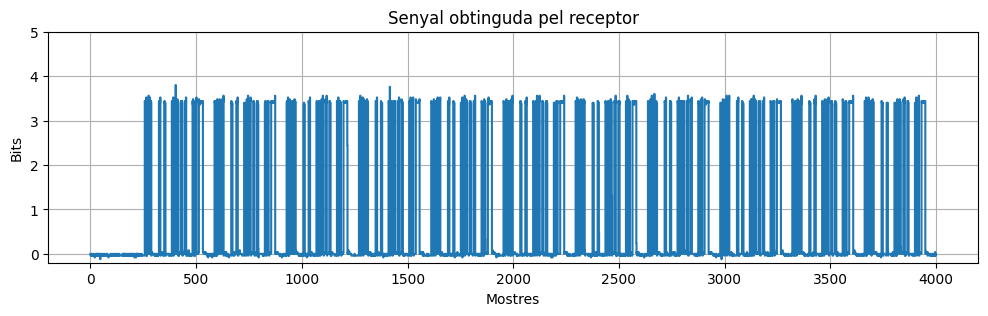

Bits per segon: 0.00244140625 bits/s
Temps per mostra: 0.000400 segons
Bits per mostra: 6.10 bits/mostra

--- MODE DECODIFICACIÓ (RX) ---
S'han trobat 10 frames a 6.103515625 samples/bit.
--> Frame trobat a mostra 587:
    Bits totals: 101010100000010001000001010100100100000101001110
    BPM detectat: 4
 Missatge a mostra 587: 'ARAN'


4

In [3]:
tx_rx_system.convertir_senyal_osciloscopi(senyal_csv="fitxers/senyal_osv2.csv", senyal_neta_csv="fitxers/senyal_osv2_neta.csv")
signal = np.loadtxt("fitxers/senyal_osv2_neta.csv", delimiter=',')

plt.figure(figsize=(12,3))
plt.step(range(len(signal)), signal, where='post')
plt.ylim(-0.2, 5)
plt.xlabel("Mostres")
plt.ylabel("Bits")
plt.title("Senyal obtinguda pel receptor")
plt.grid()
plt.show()

time_recording = 10 #segons
total_bits_sended = 4096
time_bit = time_recording/total_bits_sended 
print(f"Bits per segon: {time_bit} bits/s") 

sampling_rate = 2500 #de l'oscil.loscopi
time_per_sample = 1/sampling_rate
print(f"Temps per mostra: {time_per_sample:.6f} segons")

bits_per_sample = time_bit / time_per_sample
print(f"Bits per mostra: {bits_per_sample:.2f} bits/mostra")

tx_rx_system.decodificar(senyal_csv="fitxers/senyal_osv2_neta.csv", mode="OOK", bits_per_sample=bits_per_sample)


## MODULACIÓ MANCHESTER AMB SENYAL SIMULADA

### 1. Codificació del Senyal


Senyal guardat a fitxers/senyal.csv
Executing: python3 utils/csv2arb.py fitxers/senyal.csv
Conversion complete. ARB file saved as 'fitxers/senyal.arb'.


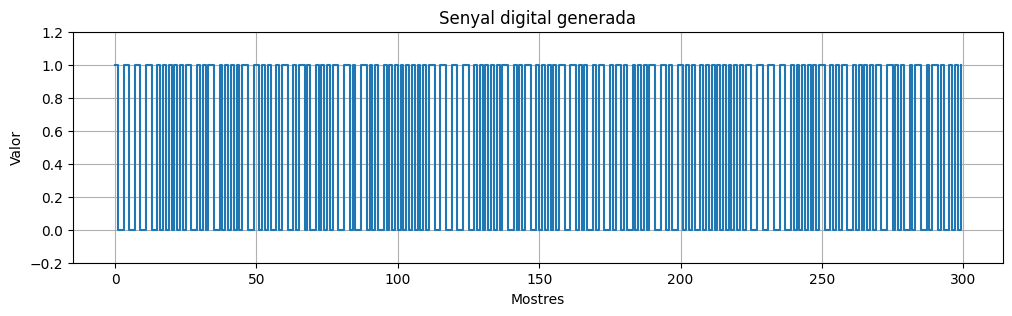

In [4]:
tx_rx_system.codificar(mode="MANCHESTER", message="Aran", num_repeats=4)
signal = np.loadtxt("fitxers/senyal.csv", delimiter=',')[:300]

plt.figure(figsize=(12,3))
plt.step(range(len(signal)), signal, where='post')
plt.ylim(-0.2, 1.2)
plt.xlabel("Mostres")
plt.ylabel("Valor")
plt.title("Senyal digital generada")
plt.grid()
plt.show()

### 2. Descodificació del Senyal 


In [5]:
"""tx_rx_system.convertir_senyal_osciloscopi(senyal_csv="fitxers/senyal.csv", senyal_neta_csv="fitxers/senyal_osv3_neta.csv")
signal = np.loadtxt("fitxers/senyal_osv3_neta.csv", delimiter=',')
plt.figure(figsize=(12,3))
plt.step(range(len(signal)), signal, where='post')
plt.ylim(-0.2, 1.2)
plt.xlabel("Mostres")
plt.ylabel("Valor")
plt.title("Senyal obtinguda pel receptor")
plt.grid()
plt.show()"""

tx_rx_system.decodificar(senyal_csv="fitxers/senyal.csv", mode="MANCHESTER", bits_per_sample=1)


--- MODE DECODIFICACIÓ (RX) ---
S'han trobat 4 frames a 1 samples/bit.
--> Frame trobat a mostra 0:
    Bits totals: 101010100000010001000001011100100110000101101110
    BPM detectat: 4
 Missatge a mostra 0: 'Aran'


4

## MODULACIÓ OOK AMB SENYAL REAL

### 1. Obtenció del senyal del transmissor i del receptor (oscil·loscopi)

Utilitzant la mateixa lògica de codificació que en els exemples anteriors, i mitjançant l’script `utils/codificacio_rasp.py` a la Raspberry Pi, es genera el senyal a partir del BPM obtingut pel sensor MAX3012 i s’envia al transmissor (driver).

A continuació, el senyal és capturat al receptor mitjançant l’oscil·loscopi. El *recording* obtingut conté tant el senyal transmès com el senyal rebut, tal com es mostra al gràfic següent.


Guardat: fitxers/tx_rx_real_neta_rx.csv i fitxers/tx_rx_real_neta_tx.csv


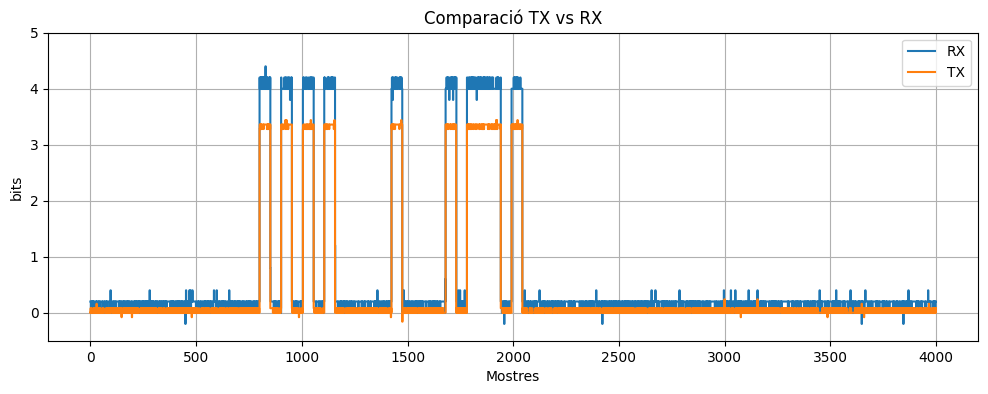

In [6]:
tx_rx_system.convertir_senyal_osciloscopi(senyal_csv="fitxers/tx_rx_real.csv", senyal_neta_csv="fitxers/tx_rx_real_neta.csv", channels=2)
signal_rx = np.loadtxt("fitxers/tx_rx_real_neta_rx.csv", delimiter=',') 
signal_tx = np.loadtxt("fitxers/tx_rx_real_neta_tx.csv", delimiter=',')

plt.figure(figsize=(12,4))

plt.step(range(len(signal_rx)), signal_rx, where='post', label='RX')
plt.step(range(len(signal_tx)), signal_tx, where='post', label='TX')

plt.ylim(-0.5, 5)
plt.xlabel("Mostres")
plt.ylabel("bits")

plt.title("Comparació TX vs RX")
plt.legend()
plt.grid()

plt.show()

### 2. Descodificació del senyal

Per tal de descodificar el senyal rebut, primer es calculen els paràmetres temporals necessaris:

- El **temps de bit** del transmissor indicar a codificacio_rasp.py és: `time_bit = 0.02`
- L’oscil·loscopi treballa amb una freqüència de mostreig de: `time_per_sample = 1/sampling_rate`
- A partir d’aquests valors, es calcula el nombre de mostres per bit: `bits_per_sample = time_bit / time_per_sample`
- Finalment, es crida la funció de descodificació, per tal de recuperar el missatge original.

In [7]:
time_bit = 0.02; # extret de utils/codificacio_rasp.py 
print(f"Període bit transmisor: {time_bit} bits/s") 

sampling_rate = 2500 #de l'oscil.loscopi
time_per_sample = 1/sampling_rate
print(f"Temps per mostra oscil·loscopi: {time_per_sample:.6f} segons")

bits_per_sample = time_bit / time_per_sample
print(f"Bits per mostra: {bits_per_sample:.2f} bits/mostra")

tx_rx_system.decodificar(senyal_csv="fitxers/tx_rx_real_neta_rx.csv", mode="OOK", bits_per_sample=bits_per_sample)


Període bit transmisor: 0.02 bits/s
Temps per mostra oscil·loscopi: 0.000400 segons
Bits per mostra: 50.00 bits/mostra

--- MODE DECODIFICACIÓ (RX) ---
S'han trobat 1 frames a 50.0 samples/bit.
--> Frame trobat a mostra 800:
    Bits totals: 1010101000001000001011101000000000000000000000000000000000000000
    BPM detectat: 46
 Missatge a mostra 800: '.    '


46

### 3. Millores en la descodificació

Com es pot observar en la descodificació anterior, el BPM obtingut no és correcte, ja que la seqüència de bits total és:
`1010101000001000001011101000000000000000000000000000000000000000`

On:

- `10101010` correspon a la *start sequence*  
- `00001000` indica la longitud del missatge (8 bits)  
- `001011101000000000000000000000000000000000000000` és el missatge rebut, però es veu truncat a `00101110`, ignorant l’últim bit `1`

Això indica que el càlcul del *sampling rate* no és estable. Si s’observa el fitxer `fitxers/tx_rx_real_2_neta_1.csv`, es pot veure que el mostreig no és constant: en alguns casos és 50, en d’altres 49 o 51 mostres per bit. Tot i que el sistema hauria de ser fix, la Raspberry Pi pot desincronitzar-se i introduir variacions en el `bit_time`, provocant errors en la descodificació.

Per aquest motiu, s’ha implementat una nova funció `decodificacio_v2`, basada en la detecció de flancs de pujada i baixada per estimar de manera adaptativa el *sampling rate* i millorar la descodificació.

In [8]:

tx_rx_system.decodificar_v2(senyal_csv="fitxers/tx_rx_real_neta_rx.csv", mode="OOK", bits_per_sample=bits_per_sample)


--- MODE DECODIFICACIÓ V2 (per flancs) ---

--> Frame a bit 0
Bits Totals: 101010100000100001011101
Missatge: '93'


93